#### Refrence from  TensorFlow whitepapers.
#### MyModule: UFCFUR-15-3: AAI- for Group project

### UFCFUR-15-3 Advance Artificail Intelligence
### Practical-5: Classification Model
### Objectives: 
     #### 1. Image Classification
     #### 2. Tensor flow Library
     #### 3.  standardize the data
     #### 4. Overfitting of Model
     #### 5. Data Augumentation
     #### 6. Rerun the Model
     #### 7. Evaluate the accuracy

## Setup

Import TensorFlow and other necessary libraries:

In [38]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
import os

## Download and explore the dataset

This tutorial uses a dataset of about 3,700 photos of flowers. The dataset contains five sub-directories, one per class:

```
flower_photo/
  daisy/
  dandelion/
  roses/
  sunflowers/
  tulips/
```

In [39]:
import tensorflow as tf
import pathlib

data_dir = pathlib.Path("flower_photos").with_suffix('')


img_height = 180
img_width = 180
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

class_names = train_ds.class_names
print(class_names)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.
['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


After downloading, you should now have a copy of the dataset available. There are 3,670 total images:

In [40]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [41]:
def build_cnn():
    model = keras.Sequential([
        layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),

        layers.Conv2D(16, 3, activation='relu'),
        layers.MaxPooling2D(),

        layers.Conv2D(32, 3, activation='relu'),
        layers.MaxPooling2D(),

        layers.Conv2D(64, 3, activation='relu'),
        layers.MaxPooling2D(),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(len(class_names))
    ])

    model.compile(
        optimizer='adam',
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=['accuracy']
    )

    return model

In [42]:
epochs = 5

cnn_model = build_cnn()

history = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 63s 519ms/step - accuracy: 0.3429 - loss: 1.6389 - val_accuracy: 0.5354 - val_loss: 1.1344
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 49s 528ms/step - accuracy: 0.5870 - loss: 1.0367 - val_accuracy: 0.5967 - val_loss: 1.0299
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 50s 539ms/step - accuracy: 0.6780 - loss: 0.8531 - val_accuracy: 0.6444 - val_loss: 0.9203
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 48s 526ms/step - accuracy: 0.7500 - loss: 0.6834 - val_accuracy: 0.6362 - val_loss: 0.9265
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 44s 477ms/step - accuracy: 0.8432 - loss: 0.4709 - val_accuracy: 0.6403 - val_loss: 0.9903


In [44]:
cnn_model.save("cnn_model.h5")

In [45]:
def build_resnet():
    base_model = tf.keras.applications.ResNet50(
        input_shape=(img_height, img_width, 3),
        include_top=False,
        weights='imagenet',
        pooling='avg'
    )

    base_model.trainable = False

    model = keras.Sequential([
        base_model,
        layers.Dense(len(class_names))
    ])

    model.compile(
        optimizer='adam',
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=['accuracy']
    )

    return model

In [46]:
resnet_model = build_resnet()

history_resnet = resnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 467s 5s/step - accuracy: 0.6046 - loss: 1.0400 - val_accuracy: 0.8147 - val_loss: 0.4953
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 398s 4s/step - accuracy: 0.8483 - loss: 0.4201 - val_accuracy: 0.8610 - val_loss: 0.4059
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 345s 4s/step - accuracy: 0.9090 - loss: 0.3000 - val_accuracy: 0.8542 - val_loss: 0.3822
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 351s 4s/step - accuracy: 0.9273 - loss: 0.2430 - val_accuracy: 0.8678 - val_loss: 0.3977
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 473s 5s/step - accuracy: 0.9393 - loss: 0.1926 - val_accuracy: 0.8638 - val_loss: 0.3538


In [47]:
resnet_model.save("resnet.h5")

In [25]:
from PIL import Image

def predict_image(model_path, image_path):
    model = tf.keras.models.load_model(model_path)

    img = Image.open(image_path).resize((180,180))
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    predictions = model.predict(img_array)
    score = tf.nn.softmax(predictions[0])

    return class_names[np.argmax(score)], np.max(score)

In [29]:
label, confidence = predict_image("cnn_model.h5", "test.jpg")
print("Prediction:", label)
print("Confidence:", confidence)

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\2030\\Desktop\\AAI\\CNNStream\\test.jpg'

Create plots of the loss and accuracy on the training and validation sets:

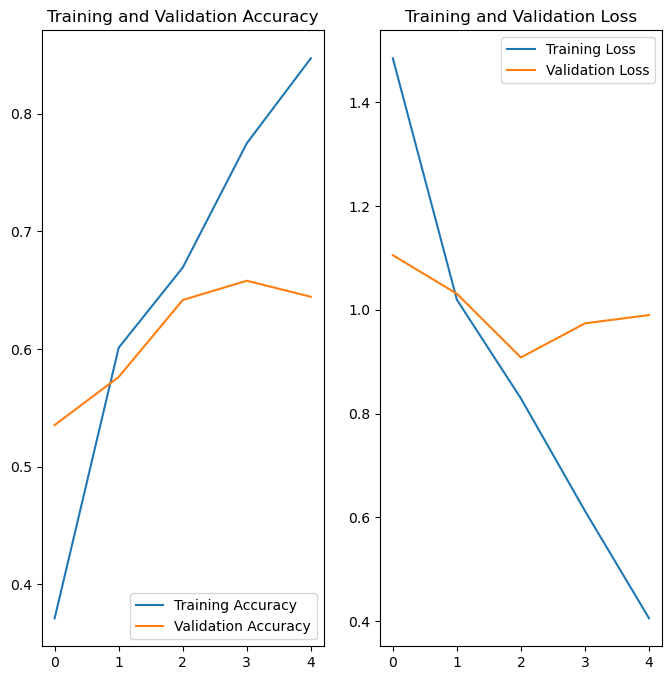

In [48]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

The plots show that training accuracy and validation accuracy are off by large margins, and the model has achieved only around 60% accuracy on the validation set.

The following tutorial sections show how to inspect what went wrong and try to increase the overall performance of the model.

In [58]:
new_predict= "lilliy_predict.jpg"
# sunflower_path = tf.keras.utils.get_file('lilliy_predict.jpg')

img = tf.keras.utils.load_img(
    new_predict, target_size=(img_height, img_width)
)
img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0) # Create a batch

predictions = model.predict(img_array)
score = tf.nn.softmax(predictions[0])

print(
    "This image most likely belongs to {} with a {:.2f} percent confidence."
    .format(class_names[np.argmax(score)], 100 * np.max(score))
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step
This image most likely belongs to roses with a 68.20 percent confidence.
